<a href="https://colab.research.google.com/github/prakriti459/PRAKRITI.23FE10CSE00459-ML-LAB-WORK/blob/main/Customer_Product_Reorder_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

In [ ]:
orders = pd.read_csv("/content/orders.csv")
prior = pd.read_csv("/content/order_products__prior.csv")
train = pd.read_csv("/content/order_products__train.csv")
products = pd.read_csv("/content/products.csv")

In [ ]:
print("orders shape:", orders.shape)
print("prior shape:", prior.shape)
print("train shape:", train.shape)
print("products shape:", products.shape)

orders shape: (3421083, 7)
prior shape: (32434489, 4)
train shape: (1384617, 4)
products shape: (49688, 4)


In [ ]:
orders.head()


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [ ]:
products.head()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [ ]:
orders.columns

Index(['order_id', 'user_id', 'eval_set', 'order_number', 'order_dow',
       'order_hour_of_day', 'days_since_prior_order'],
      dtype='object')

In [ ]:
products.columns

Index(['product_id', 'product_name', 'aisle_id', 'department_id'], dtype='object')

In [ ]:
# Split orders by eval_set
prior_orders = orders[orders["eval_set"] == "prior"].copy()
train_orders = orders[orders["eval_set"] == "train"].copy()

# Merge product tables with matching order metadata
prior_data = pd.merge(prior, prior_orders, on="order_id", how="left")
train_data = pd.merge(train, train_orders, on="order_id", how="left")

print("prior_data shape:", prior_data.shape)
print("train_data shape:", train_data.shape)


prior_data shape: (32434489, 10)
train_data shape: (1384617, 10)


In [ ]:
# Make prior_data smaller before feature engineering
prior_data = prior_data.sample(n=min(400000, len(prior_data)), random_state=42).reset_index(drop=True)
train_data = train_data.sample(n=min(150000, len(train_data)), random_state=42).reset_index(drop=True)

print("Reduced prior_data shape:", prior_data.shape)
print("Reduced train_data shape:", train_data.shape)


Reduced prior_data shape: (400000, 10)
Reduced train_data shape: (150000, 10)


In [ ]:
# Build features from prior_data only
product_reorder_rate = prior_data.groupby("product_id")["reordered"].mean().reset_index()
product_reorder_rate.columns = ["product_id", "product_reorder_rate"]

user_order_count = prior_data.groupby("user_id")["order_number"].max().reset_index()
user_order_count.columns = ["user_id", "user_total_orders"]

user_product_count = prior_data.groupby(["user_id", "product_id"]).size().reset_index(name="user_product_count")

user_reorder_ratio = prior_data.groupby("user_id")["reordered"].mean().reset_index()
user_reorder_ratio.columns = ["user_id", "user_reorder_ratio"]

product_total_orders = prior_data.groupby("product_id").size().reset_index(name="product_total_orders")

user_product_reorder_rate = prior_data.groupby(["user_id", "product_id"])["reordered"].mean().reset_index()
user_product_reorder_rate.columns = ["user_id", "product_id", "user_product_reorder_rate"]

print("Feature tables created")


Feature tables created


In [ ]:
# Create final modeling table from train_data only
data = train_data.copy()

data["days_since_prior_order"] = data["days_since_prior_order"].fillna(0)

data = pd.merge(data, product_reorder_rate, on="product_id", how="left")
data = pd.merge(data, user_order_count, on="user_id", how="left")
data = pd.merge(data, user_product_count, on=["user_id", "product_id"], how="left")
data = pd.merge(data, user_reorder_ratio, on="user_id", how="left")
data = pd.merge(data, product_total_orders, on="product_id", how="left")
data = pd.merge(data, user_product_reorder_rate, on=["user_id", "product_id"], how="left")

print("Final modeling data shape:", data.shape)
data.head()


Final modeling data shape: (150000, 16)


,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_reorder_rate,user_total_orders,user_product_count,user_reorder_ratio,product_total_orders,user_product_reorder_rate
0,1523583,37203,3,0,149174,train,5,4,7,30.0,0.294118,NaN,NaN,NaN,17.0,NaN
1,2985500,35108,4,1,11333,train,11,3,12,19.0,0.637795,5.0,NaN,0.0,254.0,NaN
2,105797,37141,2,0,31224,train,18,3,10,8.0,0.553191,13.0,NaN,0.5,47.0,NaN
3,1872331,12834,7,0,137296,train,6,5,10,7.0,0.250000,NaN,NaN,NaN,4.0,NaN
4,1020675,48775,2,0,133811,train,5,2,11,8.0,0.455556,1.0,NaN,0.0,180.0,NaN


In [ ]:
# Fill remaining missing values
for col in [
    "product_reorder_rate",
    "user_total_orders",
    "user_product_count",
    "user_reorder_ratio",
    "product_total_orders",
    "user_product_reorder_rate"
]:
    data[col] = data[col].fillna(data[col].median())

print(data.isnull().sum())


order_id                     0
product_id                   0
add_to_cart_order            0
reordered                    0
user_id                      0
eval_set                     0
order_number                 0
order_dow                    0
order_hour_of_day            0
days_since_prior_order       0
product_reorder_rate         0
user_total_orders            0
user_product_count           0
user_reorder_ratio           0
product_total_orders         0
user_product_reorder_rate    0
dtype: int64


In [ ]:
# Strong ratio feature
data["user_product_order_count_ratio"] = data["user_product_count"] / (data["user_total_orders"] + 1)

print(data[["user_product_count", "user_total_orders", "user_product_order_count_ratio"]].head())


   user_product_count  user_total_orders  user_product_order_count_ratio
0                 1.0               10.0                        0.090909
1                 1.0                5.0                        0.166667
2                 1.0               13.0                        0.071429
3                 1.0               10.0                        0.090909
4                 1.0                1.0                        0.500000


In [ ]:
# Feature selection
data_model = data.drop(columns=["order_id", "user_id", "eval_set"])

X = data_model[
    [
        "product_id",
        "add_to_cart_order",
        "order_number",
        "order_dow",
        "order_hour_of_day",
        "days_since_prior_order",
        "product_reorder_rate",
        "product_total_orders",
        "user_total_orders",
        "user_product_count",
        "user_reorder_ratio",
        "user_product_reorder_rate",
        "user_product_order_count_ratio"
    ]
]

y = data_model["reordered"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (150000, 13)
y shape: (150000,)


In [ ]:
# Smaller balanced sample for modeling
model_data = X.copy()
model_data["reordered"] = y

reordered_1 = model_data[model_data["reordered"] == 1]
reordered_0 = model_data[model_data["reordered"] == 0]

sample_1 = reordered_1.sample(n=min(30000, len(reordered_1)), random_state=42)
sample_0 = reordered_0.sample(n=min(30000, len(reordered_0)), random_state=42)

data_sampled = pd.concat([sample_1, sample_0], ignore_index=True)
data_sampled = data_sampled.sample(frac=1, random_state=42).reset_index(drop=True)

X = data_sampled.drop("reordered", axis=1)
y = data_sampled["reordered"]

print("Sampled X shape:", X.shape)
print("Sampled y shape:", y.shape)
print(y.value_counts())


Sampled X shape: (60000, 13)
Sampled y shape: (60000,)
reordered
1    30000
0    30000
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("\nTrain class distribution:")
print(y_train.value_counts())
print("\nTest class distribution:")
print(y_test.value_counts())


Training set: (48000, 13)
Test set: (12000, 13)

Train class distribution:
reordered
1    24000
0    24000
Name: count, dtype: int64

Test class distribution:
reordered
1    6000
0    6000
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)


Scaled training shape: (48000, 13)
Scaled test shape: (12000, 13)


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

results = []


In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(X_train, y_train)

y_pred_dummy = dummy_model.predict(X_test)

print("Dummy Baseline Accuracy:", accuracy_score(y_test, y_pred_dummy))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dummy))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dummy))


Dummy Baseline Accuracy: 0.5

Classification Report:
               precision    recall  f1-score   support

           0       0.50      1.00      0.67      6000
           1       0.00      0.00      0.00      6000

    accuracy                           0.50     12000
   macro avg       0.25      0.50      0.33     12000
weighted avg       0.25      0.50      0.33     12000


Confusion Matrix:
 [[6000    0]
 [6000    0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr_weighted = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr_weighted.fit(X_train_scaled, y_train)

y_pred_lr_weighted = lr_weighted.predict(X_test_scaled)

print("Class-Weighted Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr_weighted))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr_weighted))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr_weighted))


Class-Weighted Logistic Regression Accuracy: 0.6651666666666667

Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.70      0.68      6000
           1       0.68      0.63      0.65      6000

    accuracy                           0.67     12000
   macro avg       0.67      0.67      0.66     12000
weighted avg       0.67      0.67      0.66     12000


Confusion Matrix:
 [[4176 1824]
 [2194 3806]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))


Random Forest Accuracy: 0.6791666666666667

Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.70      0.69      6000
           1       0.69      0.66      0.67      6000

    accuracy                           0.68     12000
   macro avg       0.68      0.68      0.68     12000
weighted avg       0.68      0.68      0.68     12000


Confusion Matrix:

[[4195 1805]
 [2045 3955]]


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=12,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

results.append(["Decision Tree", accuracy_score(y_test, y_pred_dt)])


Decision Tree Accuracy: 0.6415

Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.69      0.66      6000
           1       0.66      0.59      0.62      6000

    accuracy                           0.64     12000
   macro avg       0.64      0.64      0.64     12000
weighted avg       0.64      0.64      0.64     12000


Confusion Matrix:
 [[4170 1830]
 [2472 3528]]


In [ ]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

y_pred_nb = nb_model.predict(X_test_scaled)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))

results.append(["Naive Bayes", accuracy_score(y_test, y_pred_nb)])


Naive Bayes Accuracy: 0.5251666666666667

Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.99      0.68      6000
           1       0.87      0.06      0.11      6000

    accuracy                           0.53     12000
   macro avg       0.69      0.53      0.39     12000
weighted avg       0.69      0.53      0.39     12000


Confusion Matrix:
 [[5948   52]
 [5646  354]]


In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

svm_weighted = LinearSVC(
    class_weight="balanced",
    max_iter=5000,
    random_state=42
)

svm_weighted.fit(X_train_scaled, y_train)

y_pred_svm_weighted = svm_weighted.predict(X_test_scaled)

print("Class-Weighted SVM Accuracy:", accuracy_score(y_test, y_pred_svm_weighted))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm_weighted))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm_weighted))


Class-Weighted SVM Accuracy: 0.6649166666666667

Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.70      0.68      6000
           1       0.68      0.63      0.65      6000

    accuracy                           0.66     12000
   macro avg       0.67      0.66      0.66     12000
weighted avg       0.67      0.66      0.66     12000


Confusion Matrix:
 [[4192 1808]
 [2213 3787]]


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=15)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))

results.append(["KNN", accuracy_score(y_test, y_pred_knn)])


KNN Accuracy: 0.6535833333333333

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.69      0.67      6000
           1       0.67      0.62      0.64      6000

    accuracy                           0.65     12000
   macro avg       0.65      0.65      0.65     12000
weighted avg       0.65      0.65      0.65     12000


Confusion Matrix:
 [[4138 1862]
 [2295 3705]]


In [ ]:
from sklearn.cluster import KMeans
import numpy as np

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X_train_scaled)

train_clusters = kmeans.predict(X_train_scaled)
test_clusters = kmeans.predict(X_test_scaled)

cluster_map = {}
for cluster in [0, 1]:
    cluster_labels = y_train[train_clusters == cluster]
    cluster_map[cluster] = cluster_labels.mode()[0]

y_pred_kmeans = np.array([cluster_map[c] for c in test_clusters])

print("KMeans Accuracy:", accuracy_score(y_test, y_pred_kmeans))
print("\nClassification Report:\n", classification_report(y_test, y_pred_kmeans))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_kmeans))

results.append(["KMeans", accuracy_score(y_test, y_pred_kmeans)])


KMeans Accuracy: 0.58375

Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.91      0.68      6000
           1       0.73      0.26      0.39      6000

    accuracy                           0.58     12000
   macro avg       0.64      0.58      0.54     12000
weighted avg       0.64      0.58      0.54     12000


Confusion Matrix:
 [[5431  569]
 [4426 1574]]


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))


Gradient Boosting Accuracy: 0.6894166666666667

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.71      0.70      6000
           1       0.70      0.67      0.68      6000

    accuracy                           0.69     12000
   macro avg       0.69      0.69      0.69     12000
weighted avg       0.69      0.69      0.69     12000


Confusion Matrix:
 [[4269 1731]
 [1996 4004]]


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

gb_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.9,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))


Gradient Boosting Accuracy: 0.6866666666666666

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.71      0.69      6000
           1       0.69      0.67      0.68      6000

    accuracy                           0.69     12000
   macro avg       0.69      0.69      0.69     12000
weighted avg       0.69      0.69      0.69     12000


Confusion Matrix:
 [[4244 1756]
 [2004 3996]]


In [ ]:
!pip install xgboost -q


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))


XGBoost Accuracy: 0.6870833333333334

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.71      0.69      6000
           1       0.70      0.66      0.68      6000

    accuracy                           0.69     12000
   macro avg       0.69      0.69      0.69     12000
weighted avg       0.69      0.69      0.69     12000


Confusion Matrix:
 [[4276 1724]
 [2031 3969]]


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

ada_model = AdaBoostClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

ada_model.fit(X_train, y_train)

y_pred_ada = ada_model.predict(X_test)

print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))
print("\nClassification Report:\n", classification_report(y_test, y_pred_ada))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_ada))


AdaBoost Accuracy: 0.6710833333333334

Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.69      0.68      6000
           1       0.68      0.65      0.66      6000

    accuracy                           0.67     12000
   macro avg       0.67      0.67      0.67     12000
weighted avg       0.67      0.67      0.67     12000


Confusion Matrix:
 [[4145 1855]
 [2092 3908]]


HistGradientBoosting ROC-AUC: 0.75292425
HistGradientBoosting PR-AUC: 0.7567679433243116


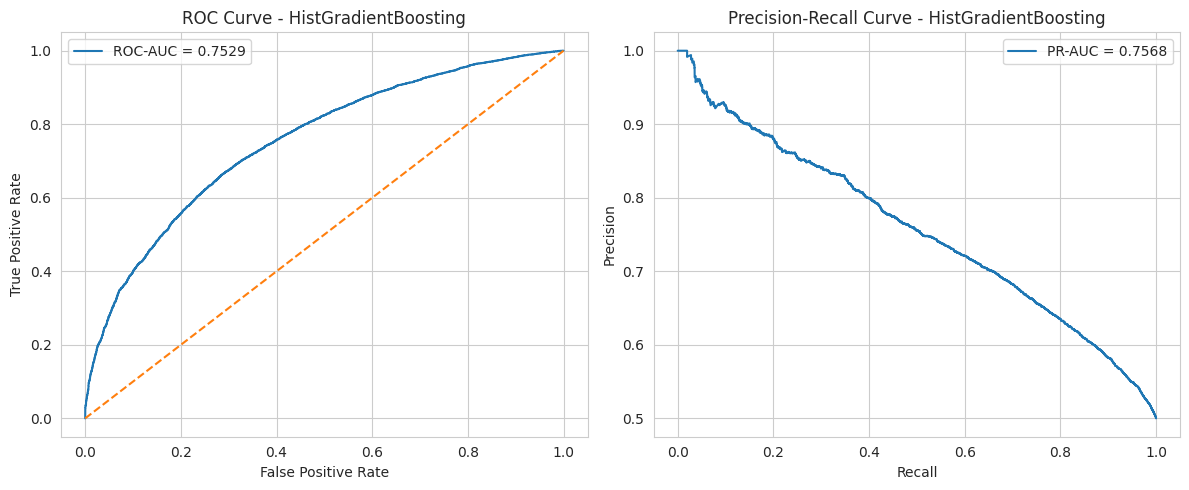

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
import matplotlib.pyplot as plt

# Probability scores for HistGradientBoosting
y_prob_hgb = hgb_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob_hgb)
pr_auc = average_precision_score(y_test, y_prob_hgb)

print("HistGradientBoosting ROC-AUC:", roc_auc)
print("HistGradientBoosting PR-AUC:", pr_auc)

fpr, tpr, _ = roc_curve(y_test, y_prob_hgb)
precision, recall, _ = precision_recall_curve(y_test, y_prob_hgb)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - HistGradientBoosting")
plt.legend()

plt.subplot(1,2,2)
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - HistGradientBoosting")
plt.legend()

plt.tight_layout()
plt.show()


                           Feature  Importance
2                     order_number    0.172459
11       user_product_reorder_rate    0.153547
6             product_reorder_rate    0.127750
1                add_to_cart_order    0.081134
10              user_reorder_ratio    0.079126
7             product_total_orders    0.072175
5           days_since_prior_order    0.066853
8                user_total_orders    0.065407
9               user_product_count    0.043095
12  user_product_order_count_ratio    0.042137
0                       product_id    0.034461
3                        order_dow    0.031061
4                order_hour_of_day    0.030795


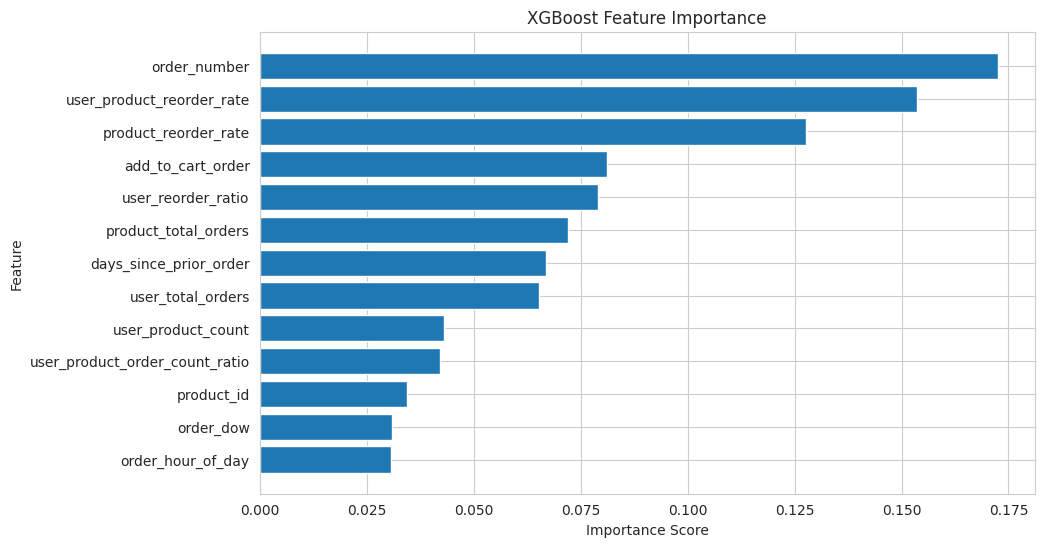

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

plt.figure(figsize=(10,6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_cv_scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("XGBoost Cross-Validation Accuracy Scores:", xgb_cv_scores)
print("Mean CV Accuracy:", np.mean(xgb_cv_scores))
print("Standard Deviation:", np.std(xgb_cv_scores))


XGBoost Cross-Validation Accuracy Scores: [0.68141667 0.67675    0.68416667 0.68033333 0.67775   ]
Mean CV Accuracy: 0.6800833333333334
Standard Deviation: 0.0026483747636784774


In [ ]:
import pandas as pd

final_results = pd.DataFrame({
    "Model": [
        "Dummy Baseline",
        "Logistic Regression",
        "Class-Weighted Logistic Regression",
        "Decision Tree",
        "Naive Bayes",
        "SVM",
        "KNN",
        "Random Forest",
        "Gradient Boosting",
        "HistGradientBoosting",
        "XGBoost",
        "KMeans"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_dummy),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_lr_weighted),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_hgb),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_kmeans)
    ]
})

final_results = final_results.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
print(final_results)


                                 Model  Accuracy
0                 HistGradientBoosting  0.688417
1                              XGBoost  0.687083
2                    Gradient Boosting  0.686667
3                        Random Forest  0.679167
4   Class-Weighted Logistic Regression  0.665167
5                  Logistic Regression  0.665167
6                                  SVM  0.664917
7                                  KNN  0.653583
8                        Decision Tree  0.641500
9                               KMeans  0.583750
10                         Naive Bayes  0.525167
11                      Dummy Baseline  0.500000


In [ ]:
print("Best model based on test accuracy:", final_results.iloc[0]["Model"])
print("Best accuracy:", final_results.iloc[0]["Accuracy"])
print("Mean XGBoost CV Accuracy:", np.mean(xgb_cv_scores))
print("HistGradientBoosting ROC-AUC:", roc_auc)
print("HistGradientBoosting PR-AUC:", pr_auc)


Best model based on test accuracy: HistGradientBoosting
Best accuracy: 0.6884166666666667
Mean XGBoost CV Accuracy: 0.6800833333333334
HistGradientBoosting ROC-AUC: 0.75292425
HistGradientBoosting PR-AUC: 0.7567679433243116
